# AE 04: NYC flights + data preprocessing
### Author: Ripa Shah
### Date: 09/17/2025

In [112]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler
import numpy as np
from nycflights13 import flights
import statsmodels.api as sm
from scipy import stats

## Exercise 1 - Load data

Fill in the blanks:


In [114]:
# add code here
df=flights
df.info()

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   year            336776 non-null  int64  
 1   month           336776 non-null  int64  
 2   day             336776 non-null  int64  
 3   dep_time        328521 non-null  float64
 4   sched_dep_time  336776 non-null  int64  
 5   dep_delay       328521 non-null  float64
 6   arr_time        328063 non-null  float64
 7   sched_arr_time  336776 non-null  int64  
 8   arr_delay       327346 non-null  float64
 9   carrier         336776 non-null  object 
 10  flight          336776 non-null  int64  
 11  tailnum         334264 non-null  object 
 12  origin          336776 non-null  object 
 13  dest            336776 non-null  object 
 14  air_time        327346 non-null  float64
 15  distance        336776 non-null  int64  
 16  hour            336776 non-null  int64  
 17  minute    

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01T10:00:00Z
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01T10:00:00Z
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01T10:00:00Z
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01T10:00:00Z
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01T11:00:00Z


The `flights` data frame has \_\_ rows.
Each row represents a \_\_.

In [115]:
sns.set(font_scale=1.5)
sns.set_theme(style="whitegrid")
flight_copy = flights.copy()

print(flight_copy)


        year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
0       2013      1    1     517.0             515        2.0     830.0   
1       2013      1    1     533.0             529        4.0     850.0   
2       2013      1    1     542.0             540        2.0     923.0   
3       2013      1    1     544.0             545       -1.0    1004.0   
4       2013      1    1     554.0             600       -6.0     812.0   
...      ...    ...  ...       ...             ...        ...       ...   
336771  2013      9   30       NaN            1455        NaN       NaN   
336772  2013      9   30       NaN            2200        NaN       NaN   
336773  2013      9   30       NaN            1210        NaN       NaN   
336774  2013      9   30       NaN            1159        NaN       NaN   
336775  2013      9   30       NaN             840        NaN       NaN   

        sched_arr_time  arr_delay carrier  flight tailnum origin dest  \
0                  819    

## Exercise 2 - Data cleaning


Remove rows with missing values in the `arr_delay` and `distance` columns.

**Your turn:** What are the names of the variables in `flights`.

In [137]:
# add code here

list_columns = ['arr_delay','distance']
flight_copy.dropna(subset=list_columns,inplace=True)
print(flight_copy)
#print(df)
#print(flight_copy.distance.to_string(index=False))
#print(flight_copy.arr_delay.to_string(index=False))

#https://stackoverflow.com/questions/64803927/how-to-drop-the-rows-if-and-only-if-values-of-particular-columns-are-missing
#https://stackoverflow.com/questions/46122910/display-print-one-column-from-a-dataframe-of-series-in-pandas


        year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
0       2013      1    1     517.0             515        2.0     830.0   
1       2013      1    1     533.0             529        4.0     850.0   
2       2013      1    1     542.0             540        2.0     923.0   
3       2013      1    1     544.0             545       -1.0    1004.0   
4       2013      1    1     554.0             600       -6.0     812.0   
...      ...    ...  ...       ...             ...        ...       ...   
336765  2013      9   30    2240.0            2245       -5.0    2334.0   
336766  2013      9   30    2240.0            2250      -10.0    2347.0   
336767  2013      9   30    2241.0            2246       -5.0    2345.0   
336768  2013      9   30    2307.0            2255       12.0    2359.0   
336769  2013      9   30    2349.0            2359      -10.0     325.0   

        sched_arr_time  arr_delay carrier  ...  distance hour minute  \
0                  819     

## Exercise 3 - Original Data Distribution


-   Plot the original distributions of `arr_delay` and `distance`.


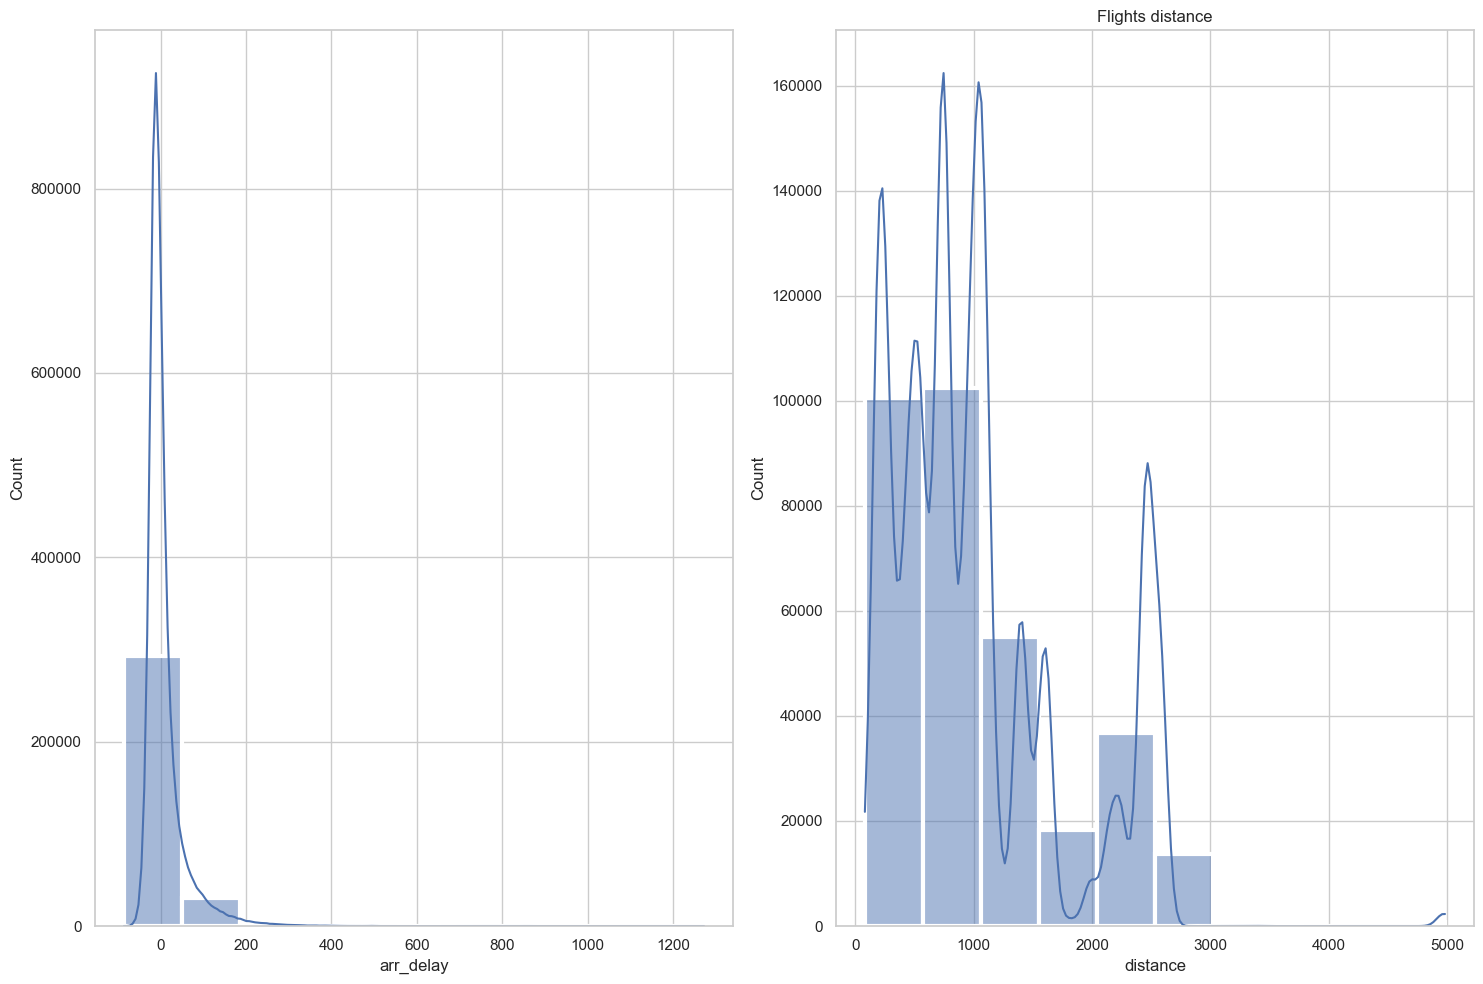

In [117]:
# add code here

# fig, (ax1,ax2) = plt.subplots(ncols = 2 , nrows = 1)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,10))
ax = ax.ravel()
sns.histplot(data=flight_copy['arr_delay'],bins=10,kde=True, linewidth = 3,ax=ax[0])
# ax1.xlabel(xlabel='Flights Arrival Delay',loc='center',fontsize=12)
# ax[0].set_title("Flights Arrival delays")


sns.histplot(data=flight_copy['distance'],bins=10,kde=True, linewidth = 3, ax=ax[1])
# ax2.xlabel(xlabel='Flights distance',loc='center',fontsize=12)
ax[1].set_title("Flights distance")
fig.tight_layout()
# plt.show()


## Exercise 4 - Check for Skewness


-   Calculate and print the skewness of `arr_delay` and `distance`.


In [118]:
# add code here
skew_arr_Delay = flight_copy['arr_delay'].skew()
skew_distance = flight_copy['distance'].skew()

print(f"Flights Arrival Skew: {skew_arr_Delay}")
print(f"Flight Distance SKew: {skew_distance}")


Flights Arrival Skew: 3.7168174804571876
Flight Distance SKew: 1.1133926208294949


## Exercise 5 - Scaling


-   Check the summary statistics of `arr_delay` and `distance` to see if scaling is necessary.

In [119]:
flight_copy['arr_delay'].describe()


count    327346.000000
mean          6.895377
std          44.633292
min         -86.000000
25%         -17.000000
50%          -5.000000
75%          14.000000
max        1272.000000
Name: arr_delay, dtype: float64

In [138]:
# Standard Scaling
#scaler = StandardScaler()
#flight_copy.loc[:, ['arr_delay_standard', 'distance_standard']] = scaler.fit_transform(flight_copy[['arr_delay', 'distance']])
#flight_copy.describe()
# Maximum Absolute Scaling
#max_abs_scaler = MaxAbsScaler()
#flight_copy.loc[:, ['arr_delay_maxabs', 'distance_maxabs']] = max_abs_scaler.fit_transform(flight_copy[['arr_delay', 'distance']])
#flight_copy.describe()
# Min-Max Scaling
#min_max_scaler = MinMaxScaler()
#flight_copy.loc[:, ['arr_delay_minmax', 'distance_minmax']] = min_max_scaler.fit_transform(flight_copy[['arr_delay', 'distance']])
#flight_copy.describe()

In [121]:
# add code here

flight_copy['distance'].describe()

count    327346.000000
mean       1048.371314
std         735.908523
min          80.000000
25%         509.000000
50%         888.000000
75%        1389.000000
max        4983.000000
Name: distance, dtype: float64

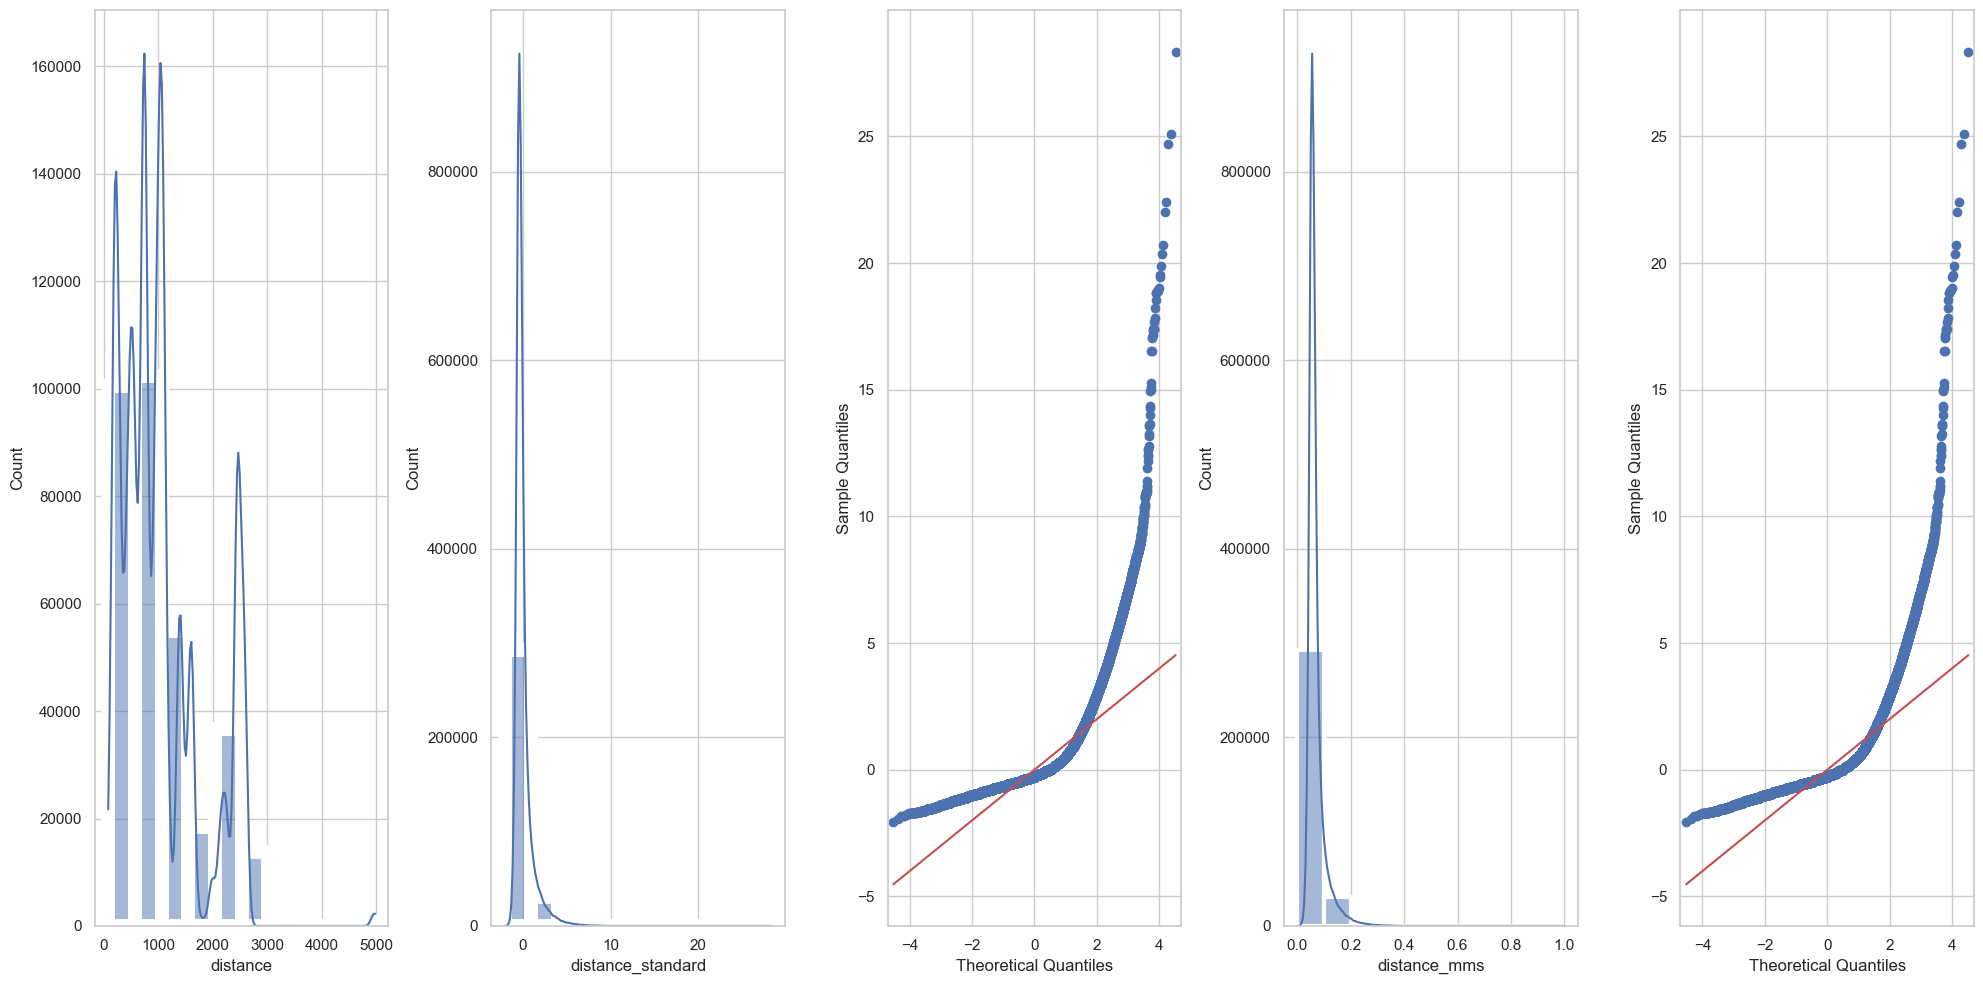

In [122]:
# add code here

fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 10))
ax = ax.ravel()
sns.histplot(data=flight_copy['distance'], kde=True, bins=10, linewidth=10, ax=ax[0])
new_flight_copy = flight_copy.copy(deep=True)

sss = StandardScaler()
new_flight_copy['distance_standard'] = sss.fit_transform(new_flight_copy.arr_delay.values.reshape((-1,1)))

sns.histplot(data=new_flight_copy['distance_standard'], kde=True, bins=10, linewidth=10, ax=ax[1])
sm.qqplot(data=new_flight_copy['distance_standard'],line='s', dist=stats.norm, fit=True, ax=ax[2])


mms = MinMaxScaler()
new_flight_copy['distance_mms'] = mms.fit_transform(new_flight_copy.arr_delay.values.reshape((-1,1)))

new_flight_copy['distance_mms'].describe()

sns.histplot(data=new_flight_copy['distance_mms'], kde=True, bins=10, ax=ax[3], linewidth=3)
sm.qqplot(data=new_flight_copy['distance_mms'],line='s', dist=stats.norm, fit=True, ax=ax[4])

plt.tight_layout()
plt.show()

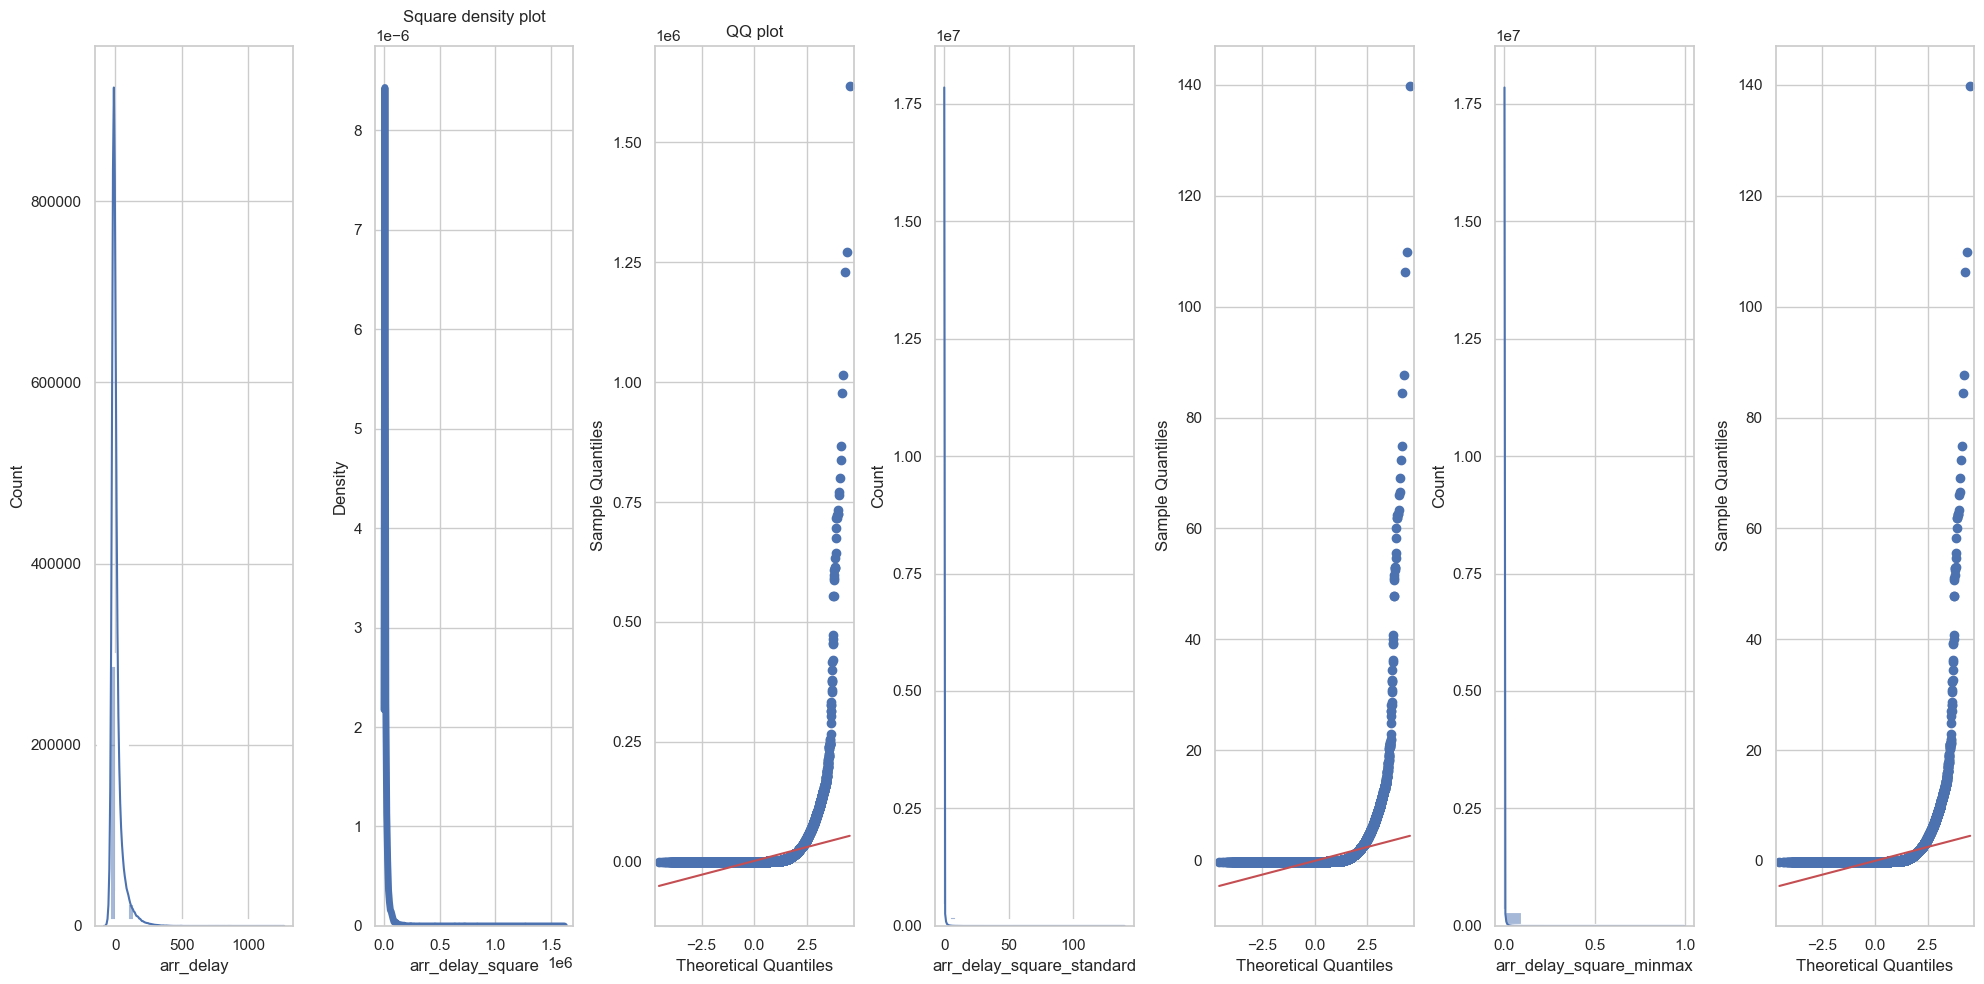

In [123]:
fig, ax = plt.subplots(nrows=1, ncols=7, figsize=(20, 10))
ax = ax.ravel()

sns.histplot(data=flight_copy['arr_delay'], kde=True, bins=10, linewidth=10, ax=ax[0])
new_flight_copy = flight_copy.copy(deep=True)

new_flight_copy['arr_delay_square']= pow(new_flight_copy['arr_delay'],2)
col= new_flight_copy['arr_delay_square']

sns.kdeplot(col, linewidth=5, ax=ax[1])
ax[1].set_title('Square density plot')

sm.qqplot(col,line='s', ax=ax[2])
ax[2].set_title('QQ plot')


sss = StandardScaler()
new_flight_copy['arr_delay_square_standard'] = sss.fit_transform(new_flight_copy.arr_delay_square.values.reshape((-1,1)))
new_flight_copy['arr_delay_square_standard'].describe()

sns.histplot(data=new_flight_copy['arr_delay_square_standard'], kde=True, bins=10, linewidth=10, ax=ax[3])
sm.qqplot(data=new_flight_copy['arr_delay_square_standard'],line='s', dist=stats.norm, fit=True, ax=ax[4])


mms = MinMaxScaler()
new_flight_copy['arr_delay_square_minmax'] = mms.fit_transform(new_flight_copy.arr_delay_square.values.reshape((-1,1)))

new_flight_copy['arr_delay_square_minmax'].describe()

sns.histplot(data=new_flight_copy['arr_delay_square_minmax'], kde=True, bins=10, ax=ax[5], linewidth=3)
sm.qqplot(data=new_flight_copy['arr_delay_square_minmax'],line='s', dist=stats.norm, fit=True, ax=ax[6])

plt.tight_layout()
plt.show()

-   Question: Do `arr_delay` and `distance` need to be scaled? Why?


After implementing describe() for arr_delay and distance, min and max values are totally different. yes, that needs to be scaled.

*add response here.*

-   Apply standard scaling, maximum absolute scaling, and Min-Max Scaling to the transformed `arr_delay` and `distance`.
-   **Hint:** use the framework `df_clean.loc[:, ['arr_delay_minmax', 'distance_minmax']]` to prevent errors

count    3.273460e+05
mean    -1.208599e-16
std      1.000002e+00
min     -1.315887e+00
25%     -7.329337e-01
50%     -2.179232e-01
75%      4.628690e-01
max      5.346636e+00
Name: distance_standard, dtype: float64
count    3.273460e+05
mean     8.335169e-18
std      1.000002e+00
min     -2.081306e+00
25%     -5.353720e-01
50%     -2.665140e-01
75%      1.591779e-01
max      2.834446e+01
Name: arr_delay_standard, dtype: float64


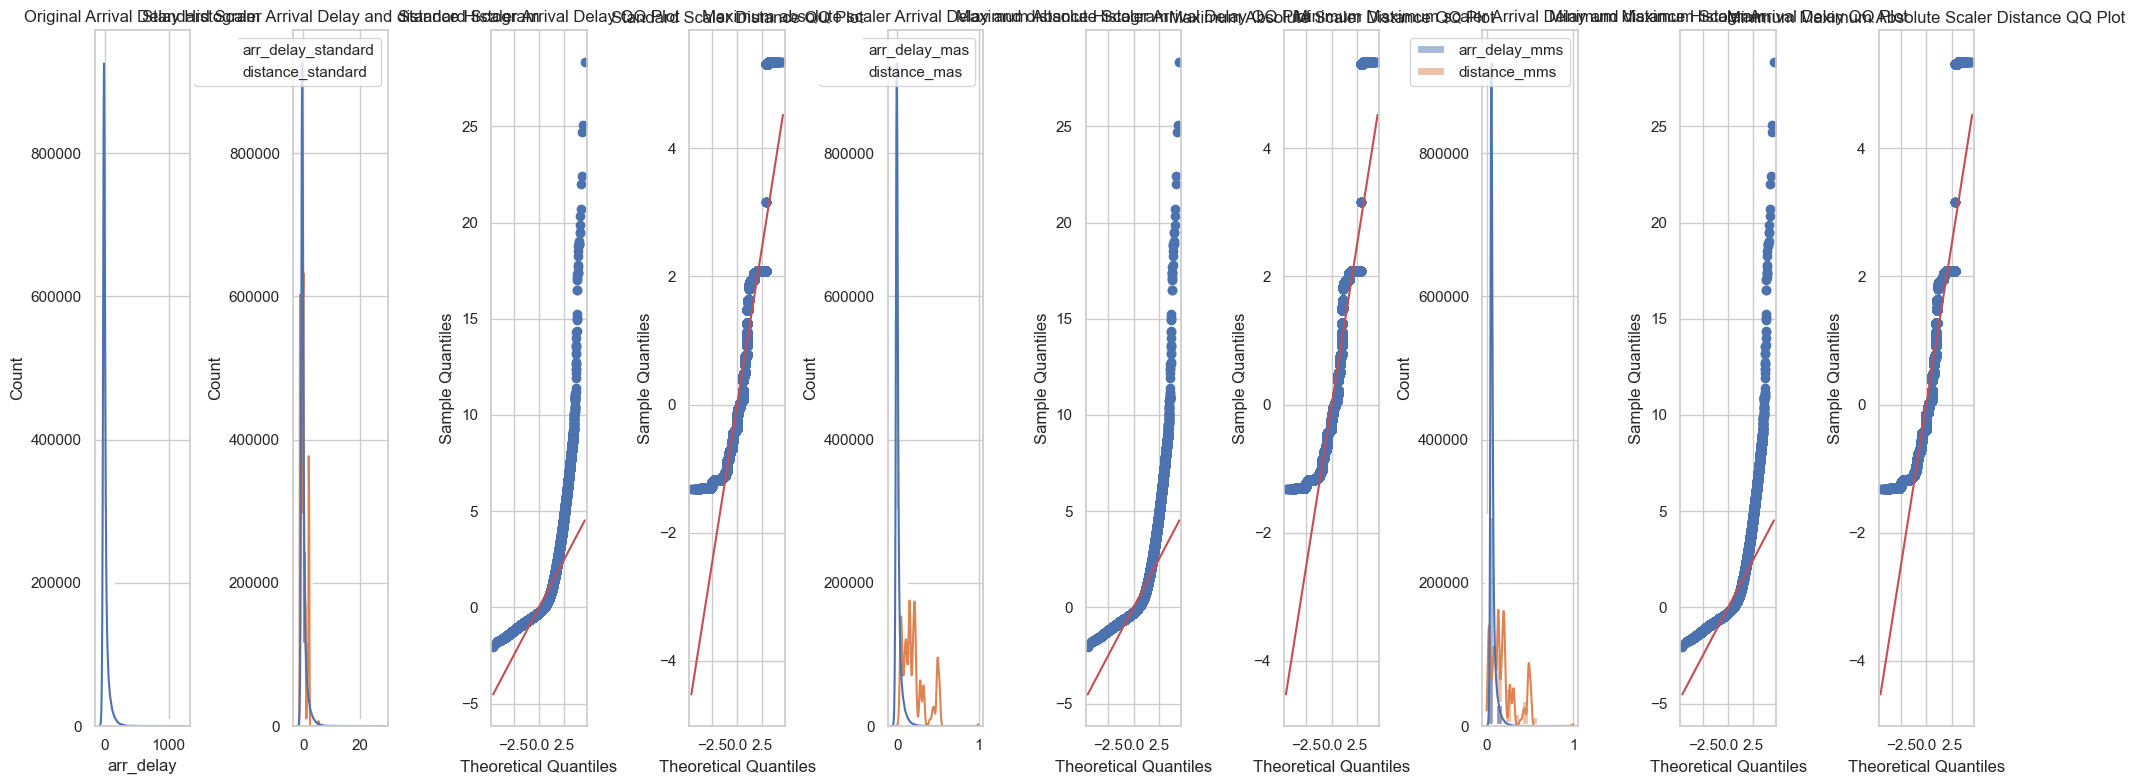

In [124]:
# add code here


fig, ax = plt.subplots(nrows=1, ncols=10, figsize=(20, 8))
ax = ax.ravel()
sns.histplot(data=flight_copy['arr_delay'], kde=True, bins=10, linewidth=10, ax=ax[0])
new_flight_copy = flight_copy.copy(deep=True)
ax[0].set_title('Original Arrival Delay Histogram')

# Assuming you have the new_flight_copy DataFrame
sss = StandardScaler()

# Standardize the columns
new_flight_copy['arr_delay_standard'] = sss.fit_transform(new_flight_copy.arr_delay.values.reshape((-1, 1)))
new_flight_copy['distance_standard'] = sss.fit_transform(new_flight_copy.distance.values.reshape((-1, 1)))

# Create subplots
#fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Plot histogram with KDE
sns.histplot(data=new_flight_copy.loc[:, ['arr_delay_standard', 'distance_standard']], kde=True, bins=10, linewidth=10, ax=ax[1])
ax[1].set_title('Standard Scaler Arrival Delay and distance Histogram')

# Plot Q-Q plot for both columns
sm.qqplot(new_flight_copy['arr_delay_standard'], line='s', dist=stats.norm, fit=True, ax=ax[2])
sm.qqplot(new_flight_copy['distance_standard'], line='s', dist=stats.norm, fit=True, ax=ax[3])

ax[2].set_title('Standard Scaler Arrival Delay QQ Plot')
ax[3].set_title('Standard Scaler Distance QQ Plot')

print(new_flight_copy['distance_standard'].describe())
print(new_flight_copy['arr_delay_standard'].describe())

mas = MaxAbsScaler()

# Scale 'arr_delay' and 'distance' independently
new_flight_copy['arr_delay_mas'] = mas.fit_transform(new_flight_copy.arr_delay.values.reshape((-1, 1)))
new_flight_copy['distance_mas'] = mas.fit_transform(new_flight_copy.distance.values.reshape((-1, 1)))



# Create subplots
#fig, ax = plt.subplots(1, 5, figsize=(20, 5))  # Create a figure with 5 subplots

# Plot histogram with KDE
sns.histplot(data=new_flight_copy.loc[:, ['arr_delay_mas', 'distance_mas']], kde=True, bins=10, linewidth=10, ax=ax[4])
ax[4].set_title('Maximum absolute scaler Arrival Delay and distance Histogram')
# Plot Q-Q plot for both columns
sm.qqplot(new_flight_copy['arr_delay_mas'], line='s', dist=stats.norm, fit=True, ax=ax[5])
sm.qqplot(new_flight_copy['distance_mas'], line='s', dist=stats.norm, fit=True, ax=ax[6])
ax[5].set_title('Maximum Absolute Scaler Arrival Delay QQ Plot')
ax[6].set_title('Maximum Absolute Scaler Distance QQ Plot')

mms = MinMaxScaler()

# Scale 'arr_delay' and 'distance' independently
new_flight_copy['arr_delay_mms'] = mms.fit_transform(new_flight_copy.arr_delay.values.reshape((-1, 1)))
new_flight_copy['distance_mms'] = mms.fit_transform(new_flight_copy.distance.values.reshape((-1, 1)))

# Check the description of 'arr_delay_mms'

# Create subplots
#fig, ax = plt.subplots(1, 7, figsize=(20, 5))  # Create a figure with 7 subplots

# Plot histogram with KDE for both columns
sns.histplot(data=new_flight_copy.loc[:, ['arr_delay_mms', 'distance_mms']], kde=True, bins=10, ax=ax[7], linewidth=3)
ax[7].set_title('Minimum Maximum scaler Arrival Delay and distance Histogram')

# Plot Q-Q plot for both columns
sm.qqplot(new_flight_copy['arr_delay_mms'], line='s', dist=stats.norm, fit=True, ax=ax[8])
sm.qqplot(new_flight_copy['distance_mms'], line='s', dist=stats.norm, fit=True, ax=ax[9])
ax[8].set_title('Minimum Maximum Scaler Arrival Delay QQ Plot')
ax[9].set_title('Minimum Maximum Absolute Scaler Distance QQ Plot')


# Show the plot
plt.tight_layout()
plt.show()


-   Question: What are the two pros and two cons of standardizing data?

*Add response here.*


In [125]:
print(new_flight_copy['arr_delay'].describe())
print(new_flight_copy['distance'].describe())

count    327346.000000
mean          6.895377
std          44.633292
min         -86.000000
25%         -17.000000
50%          -5.000000
75%          14.000000
max        1272.000000
Name: arr_delay, dtype: float64
count    327346.000000
mean       1048.371314
std         735.908523
min          80.000000
25%         509.000000
50%         888.000000
75%        1389.000000
max        4983.000000
Name: distance, dtype: float64


In [126]:
print(new_flight_copy['distance_standard'].describe())
print(new_flight_copy['arr_delay_standard'].describe())

count    3.273460e+05
mean    -1.208599e-16
std      1.000002e+00
min     -1.315887e+00
25%     -7.329337e-01
50%     -2.179232e-01
75%      4.628690e-01
max      5.346636e+00
Name: distance_standard, dtype: float64
count    3.273460e+05
mean     8.335169e-18
std      1.000002e+00
min     -2.081306e+00
25%     -5.353720e-01
50%     -2.665140e-01
75%      1.591779e-01
max      2.834446e+01
Name: arr_delay_standard, dtype: float64


In [127]:
print(new_flight_copy['arr_delay_mas'].describe())
print(new_flight_copy['distance_mas'].describe())

count    327346.000000
mean          0.005421
std           0.035089
min          -0.067610
25%          -0.013365
50%          -0.003931
75%           0.011006
max           1.000000
Name: arr_delay_mas, dtype: float64
count    327346.000000
mean          0.210390
std           0.147684
min           0.016055
25%           0.102147
50%           0.178206
75%           0.278748
max           1.000000
Name: distance_mas, dtype: float64


In [128]:

print(new_flight_copy['arr_delay_mms'].describe())
print(new_flight_copy['distance_mms'].describe())

count    327346.000000
mean          0.068406
std           0.032867
min           0.000000
25%           0.050810
50%           0.059647
75%           0.073638
max           1.000000
Name: arr_delay_mms, dtype: float64
count    327346.000000
mean          0.197506
std           0.150094
min           0.000000
25%           0.087497
50%           0.164797
75%           0.266979
max           1.000000
Name: distance_mms, dtype: float64


It structures the data. We can see a specific pattern after standardizing data. In original format, you can see that arr_dealy data was between -86 and 1272 and distance data was between 80 and 4983. After implementing standard scaler on both data, I can see that distance data is between -1 and 5. Similarly, arr_delay data is between -2 and 2.

In maximum absolute scaler, I can see that distance is between 0 and 1 and arr_delay data is between -0 and 1. It's mean is 0.25 and 0.0 respectively.

In Minimum Maximum scaler, I can see that distance is between 0 and 1 and arr_delay data is between 0 and 1. It's mean is 0.19 and 0.06.
Pros:
(1) Model become easy to understand. (2) It enhance the performance of algorithm.
Cons:
Some method assumes data is normally distributed. However, it's not true in some cases.
Scaled values might lose their original meaning and units

## Exercise 6 - Transformation


-   Check the summary statistics again with your min-max standardized columns.

In [129]:
# add code here
print(new_flight_copy['arr_delay_mms'].describe())


count    327346.000000
mean          0.068406
std           0.032867
min           0.000000
25%           0.050810
50%           0.059647
75%           0.073638
max           1.000000
Name: arr_delay_mms, dtype: float64


In [130]:
# add code here
print(new_flight_copy['distance_mms'].describe())

count    327346.000000
mean          0.197506
std           0.150094
min           0.000000
25%           0.087497
50%           0.164797
75%           0.266979
max           1.000000
Name: distance_mms, dtype: float64


-   Question: Why should you use the min-max scaled data instead of a different scaling for the transformations (hint: especially log transformation)

The other transformation have negative values.

*Add response here.*


-   Apply a log transformation to `arr_delay` if it is positively skewed and apply a square root transformation to `distance` if it is negatively skewed (use `if` `else` statements).

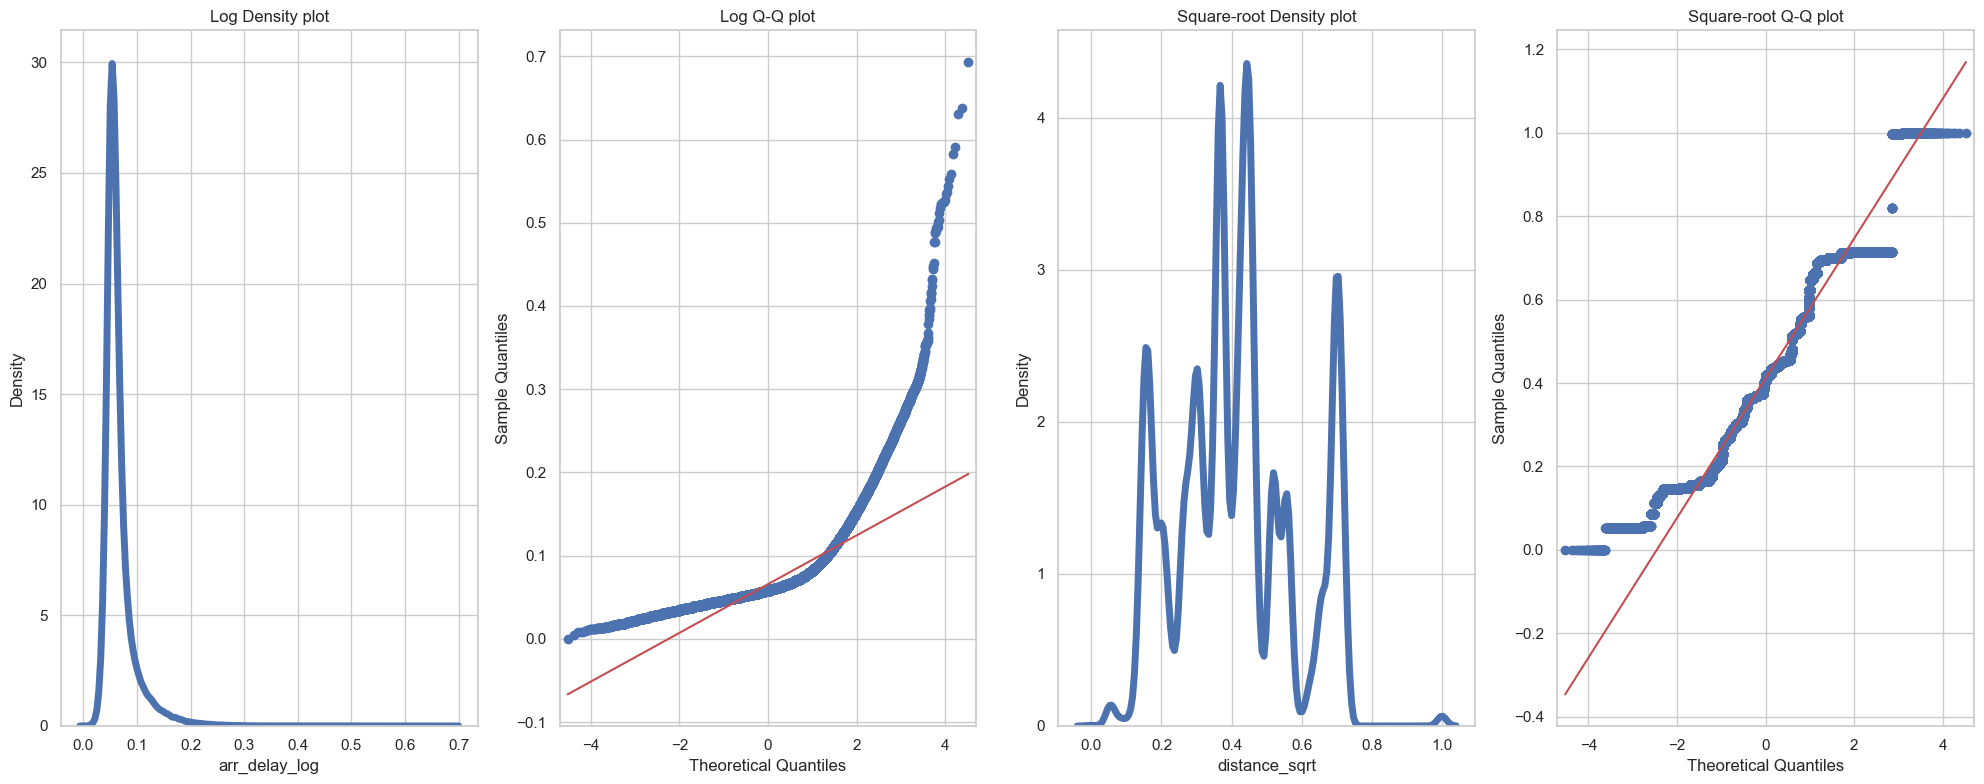

In [136]:
new_flight_copy['arr_delay_log'] = np.log(new_flight_copy['arr_delay_minmax'] + 1)
new_flight_copy['distance_sqrt'] = np.sqrt(new_flight_copy['distance_minmax'])
if skew_arr_Delay > 0:
    new_flight_copy.loc[:,'arr_delay_transformed'] = new_flight_copy['arr_delay_log']
else:
    new_flight_copy.loc[:,'arr_delay_transformed'] = new_flight_copy['arr_delay_minmax']
if skew_distance > 0:
    new_flight_copy.loc[:,'distance_transformed'] = new_flight_copy['distance_minmax']
else:
    new_flight_copy.loc[:,'distance_transformed'] = new_flight_copy['distance_sqrt']

col1 = new_flight_copy['arr_delay_log']

fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(20, 8))
ax = ax.ravel()

sns.kdeplot(col1, linewidth = 5, ax = ax[0])
ax[0].set_title('Log Density plot')    

sm.qqplot(col1, line = 's', ax = ax[1])
ax[1].set_title('Log Q-Q plot')    


col = new_flight_copy['distance_sqrt']

#fig, (ax1, ax2) = plt.subplots(ncols = 2, nrows = 1)

sns.kdeplot(col, linewidth = 5, ax = ax[2])
ax[2].set_title('Square-root Density plot')

sm.qqplot(col, line = 's', ax = ax[3])
ax[3].set_title('Square-root Q-Q plot')    
plt.tight_layout()
plt.show()


-   **Hint:** Logical operators in Python:

    | operator      | definition                                               |
    |:--------------|:---------------------------------------------------------|
    | `<`           | is less than?                                            |
    | `<=`          | is less than or equal to?                                |
    | `>`           | is greater than?                                         |
    | `>=`          | is greater than or equal to?                             |
    | `==`          | is exactly equal to?                                     |
    | `!=`          | is not equal to?                                         |
    | `x and y`     | is x AND y?                                              |
    | `x or y`      | is x OR y?                                               |
    | `pd.isna(x)`  | is x NA?                                                 |
    | `~pd.isna(x)` | is x not NA?                                             |
    | `x in y`      | is x in y?                                               |
    | `x not in y`  | is x not in y?                                           |
    | `not x`       | is not x? (only makes sense if `x` is `True` or `False`) |

In [ ]:
# add code here


-   Question: Why do we have to add a constant when we perform a log or square-root transformation (i.e., `np.log1p(df['column' + 1])`)?

log and square root functions do not contain 0 and negative numbers.

*add response here.*
